In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
from datetime import datetime, timedelta
import polars as pl

from thrs.control.modules.lt2 import Lt2Control, Lt2Parameters
from thrs.input_output.alarms import BaseAlarms
from thrs.input_output.base import Stamped
from thrs.input_output.definitions.simulation import (
    Boundary,
    Converter,
)
from thrs.input_output.modules.lt2 import (
    Lt2ControlValues,
    Lt2SensorValues,
    Lt2SimulationInputs,
    Lt2SimulationOutputs,
)
from thrs.orchestration.simulator import Simulator, SimulatorModel

from thrs.simulation.models.fmu_paths import lt2_path

start_time = datetime.fromtimestamp(0)
minutes = 30
duration = timedelta(minutes=minutes - 1)
time_index = pl.datetime_range(
    start_time,
    start_time + duration,
    interval="1m",
    time_unit="us",
    eager=True,
)

SEAWATER_TEMPERATURE = 20.0

simulation_inputs = Lt2SimulationInputs(
    lt2_brightloop_fwd1=Converter(
        heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)
    ),
    lt2_brightloop_fwd2=Converter(
        heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)
    ),
    lt2_ugrid1=Converter(heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)),
    lt2_ugrid2=Converter(heat_flow=Stamped.stamp(0), active=Stamped.stamp(False)),
    lt2_brightloop_aft1=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    lt2_brightloop_aft2=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    lt2_brightloop_aft3=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    lt2_brightloop_aft4=Converter(
        heat_flow=Stamped.stamp(500), active=Stamped.stamp(True)
    ),
    lt2_seawater_supply=Boundary(
        temperature=Stamped.stamp(SEAWATER_TEMPERATURE), flow=Stamped.stamp(64)
    ),
    lt2_boilers_supply=Boundary(temperature=Stamped.stamp(35), flow=Stamped.stamp(20)),
)

parameters = Lt2Parameters(
    maximum_supply_temperature=63,
    recovery_temperature=60,
    brightloop_flow_setpoint=5,
    ugrid_flow_setpoint=20,
    brightloop_return_temperature=60,
    ugrid_return_temperature=60,
    heat_dump_tuning=(0.05, 0.01, 0.0),
    recovery_mix_tuning=(-0.01, 0.005, 0.0),
    brightloops_fwd_mix_tuning=(-0.005, 0.001, 0.0),
    brightloops_aft_mix_tuning=(-0.005, 0.001, 0.0),
    ugrids_mix_tuning=(-0.005, 0.001, 0.0),
    brightloops_fwd_pump_tuning=(0.01, 0.001, 0),
    brightloops_aft_pump_tuning=(0.01, 0.001, 0),
    ugrids_pump_tuning=(0.01, 0.001, 0),
)


lt2_model = SimulatorModel(
    fmu_path=lt2_path,
    sensor_values_cls=Lt2SensorValues,
    control_values_cls=Lt2ControlValues,
    simulation_outputs_cls=Lt2SimulationOutputs,
    simulation_inputs=simulation_inputs,
    control_cls=Lt2Control,
    control_parameters=parameters,
    alarms=BaseAlarms(),
    tick_duration=timedelta(seconds=1),
    start_time=start_time,
)
with lt2_model.executor() as executor:
    simulation = Simulator.from_model(lt2_model, executor)
    result = await simulation.run(int(duration.total_seconds()))

[WARNING] State logging: Please enable result storing to get state names
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 3.51071, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 4.43552, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 5.43974, mxstep steps taken before reaching tout.
[WARNING] CVODE: CVode failed with CV_TOO_MUCH_WORK:
 At t = 6.22865, mxstep steps taken before reaching tout.


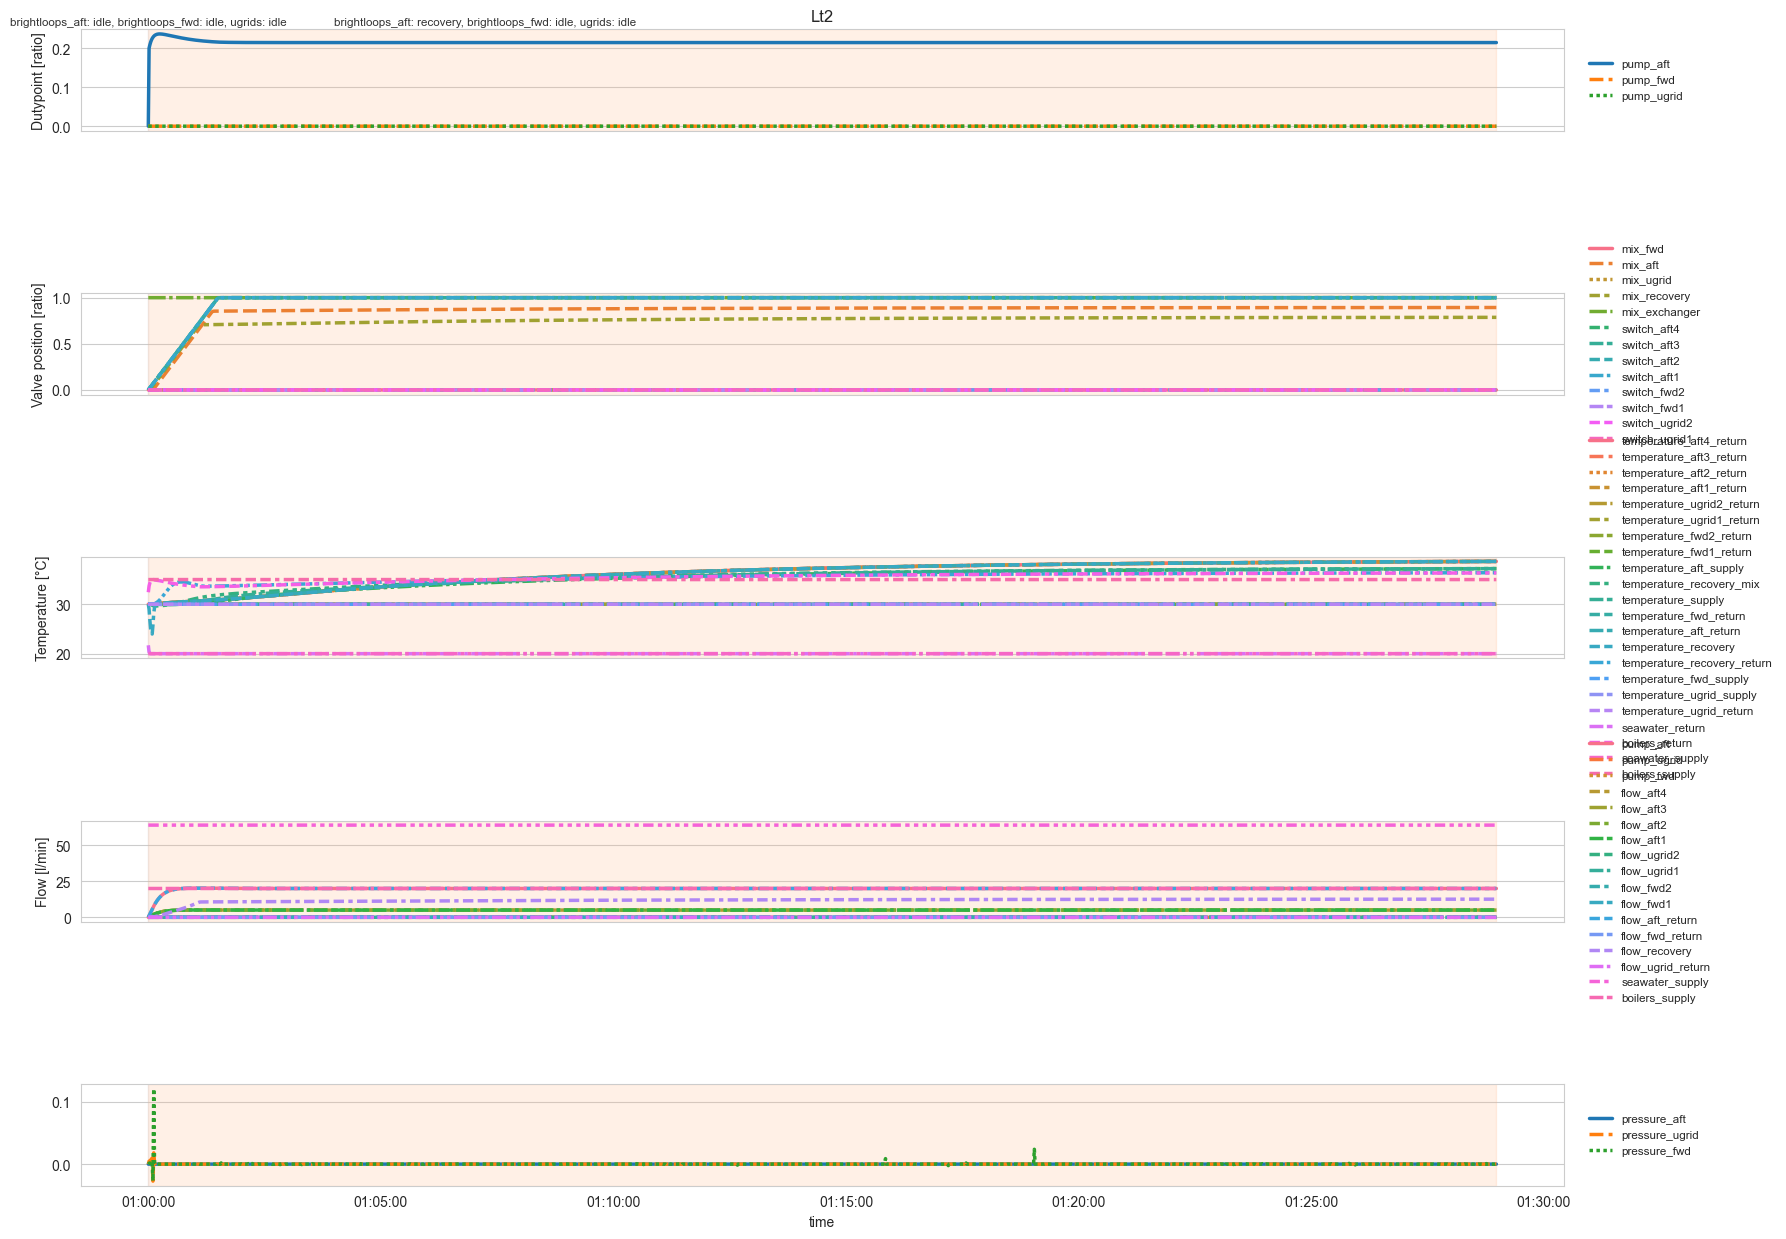

In [7]:
from analysis.analysis_utils import plot_result

plot_result(result, "plots/lt2.png");